In [1]:
import ftlelab as fl
# import ftlelab.configs as cfg
import ftlelab.models as fmods
import torch

import ftlelab.utils as utils
import ftlelab.data as datasets
import ftlelab.training as training

import jax
from tqdm import tqdm

import numpy as np
import jax.numpy as jnp
from ftlelab.ftle.jax_transfer import pytorch_dense_to_jax_params
from ftlelab.ftle.jax_core import ftle_field_batched
# jax.config.update("jax_enable_x64", True)

%load_ext autoreload
%autoreload 2

In [2]:
import ftlelab.ftle as ftle

In [3]:
X_circ, y_circ = datasets.make_circle_dataset(num_samples=15000,
                                              noise_std=0.1,
                                              seed=42)

data_circ = datasets.make_dataloaders(datasets.split_dataset(X_circ, y_circ), batch_size=12000)

In [4]:
net_1 = fmods.DenseNet([2, 10, 3, 10, 3, 10, 1], init_method="paper", output_activation="tanh")

In [20]:
config_c1 = training.TrainConfig(
    epochs=2000,
    batch_size=12000,
    optimizer='sgd',
    print_every=100,
    model_name="1",
    lr=1e-2
)

In [21]:
trainer = training.Trainer(net_1, config_c1)

Trainer for MODEL_1 initialized on device: cuda
Trainable parameters: 187 / 187


In [ ]:
results_1 = trainer.train(data_circ['train'], data_circ['val'])

In [4]:
net_1 = fmods.DenseNet([2, 10, 3, 10, 3, 10, 1], init_method="paper", output_activation="tanh")
net_1.load_state_dict(torch.load(f"checkpoints/BEST_MODEL1.pt")['model_state_dict']);

In [21]:
# 1. Load your trained PyTorch DenseNet
net_1.eval()

# 2. Convert to JAX params
params_jax = pytorch_dense_to_jax_params(net_1)

# 3. Build a grid of points in numpy (similar to grid.make_grid2d)
xs = np.linspace(-1.2, 1.2, 200, dtype=np.float32)
ys = np.linspace(-1.2, 1.2, 200, dtype=np.float32)
XX, YY = np.meshgrid(xs, ys, indexing="xy")
grid_np = np.stack([XX.reshape(-1), YY.reshape(-1)], axis=1)  # (N, 2)

X_jax = jnp.asarray(grid_np)


l_list = [10, 3, 10, 3, 10]
grids_jax = []
for i in range(1, 6):
    layer_spec = ("hidden_k", i)

    lam_np = ftle_field_batched(
        model_type="dense",
        params=params_jax,
        X_np=grid_np,
        layer_spec=("hidden_k", i),
        time_L=i,
        batch_size=2048,
        activation="tanh",
        output_activation="tanh",
        dtype="float32",
        max_steps=30
    )
    lam_np.reshape(YY.shape)  # reshape to (ny, nx) for plotting
    grids_jax.append(lam_np)
# 4. Compute FTLE field for last hidden layer (say depth L_hidden)




FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

In [33]:
net_1.eval()
grid, _ = ftle.make_grid2d()

l_list = [10, 3, 10, 3, 10]
grids = []
for i in range(1, 6):
    gridd = ftle.compute_ftle_grid(net_1, ("hidden_k", i), time_L=i, grid=grid)
    grids.append(gridd)

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

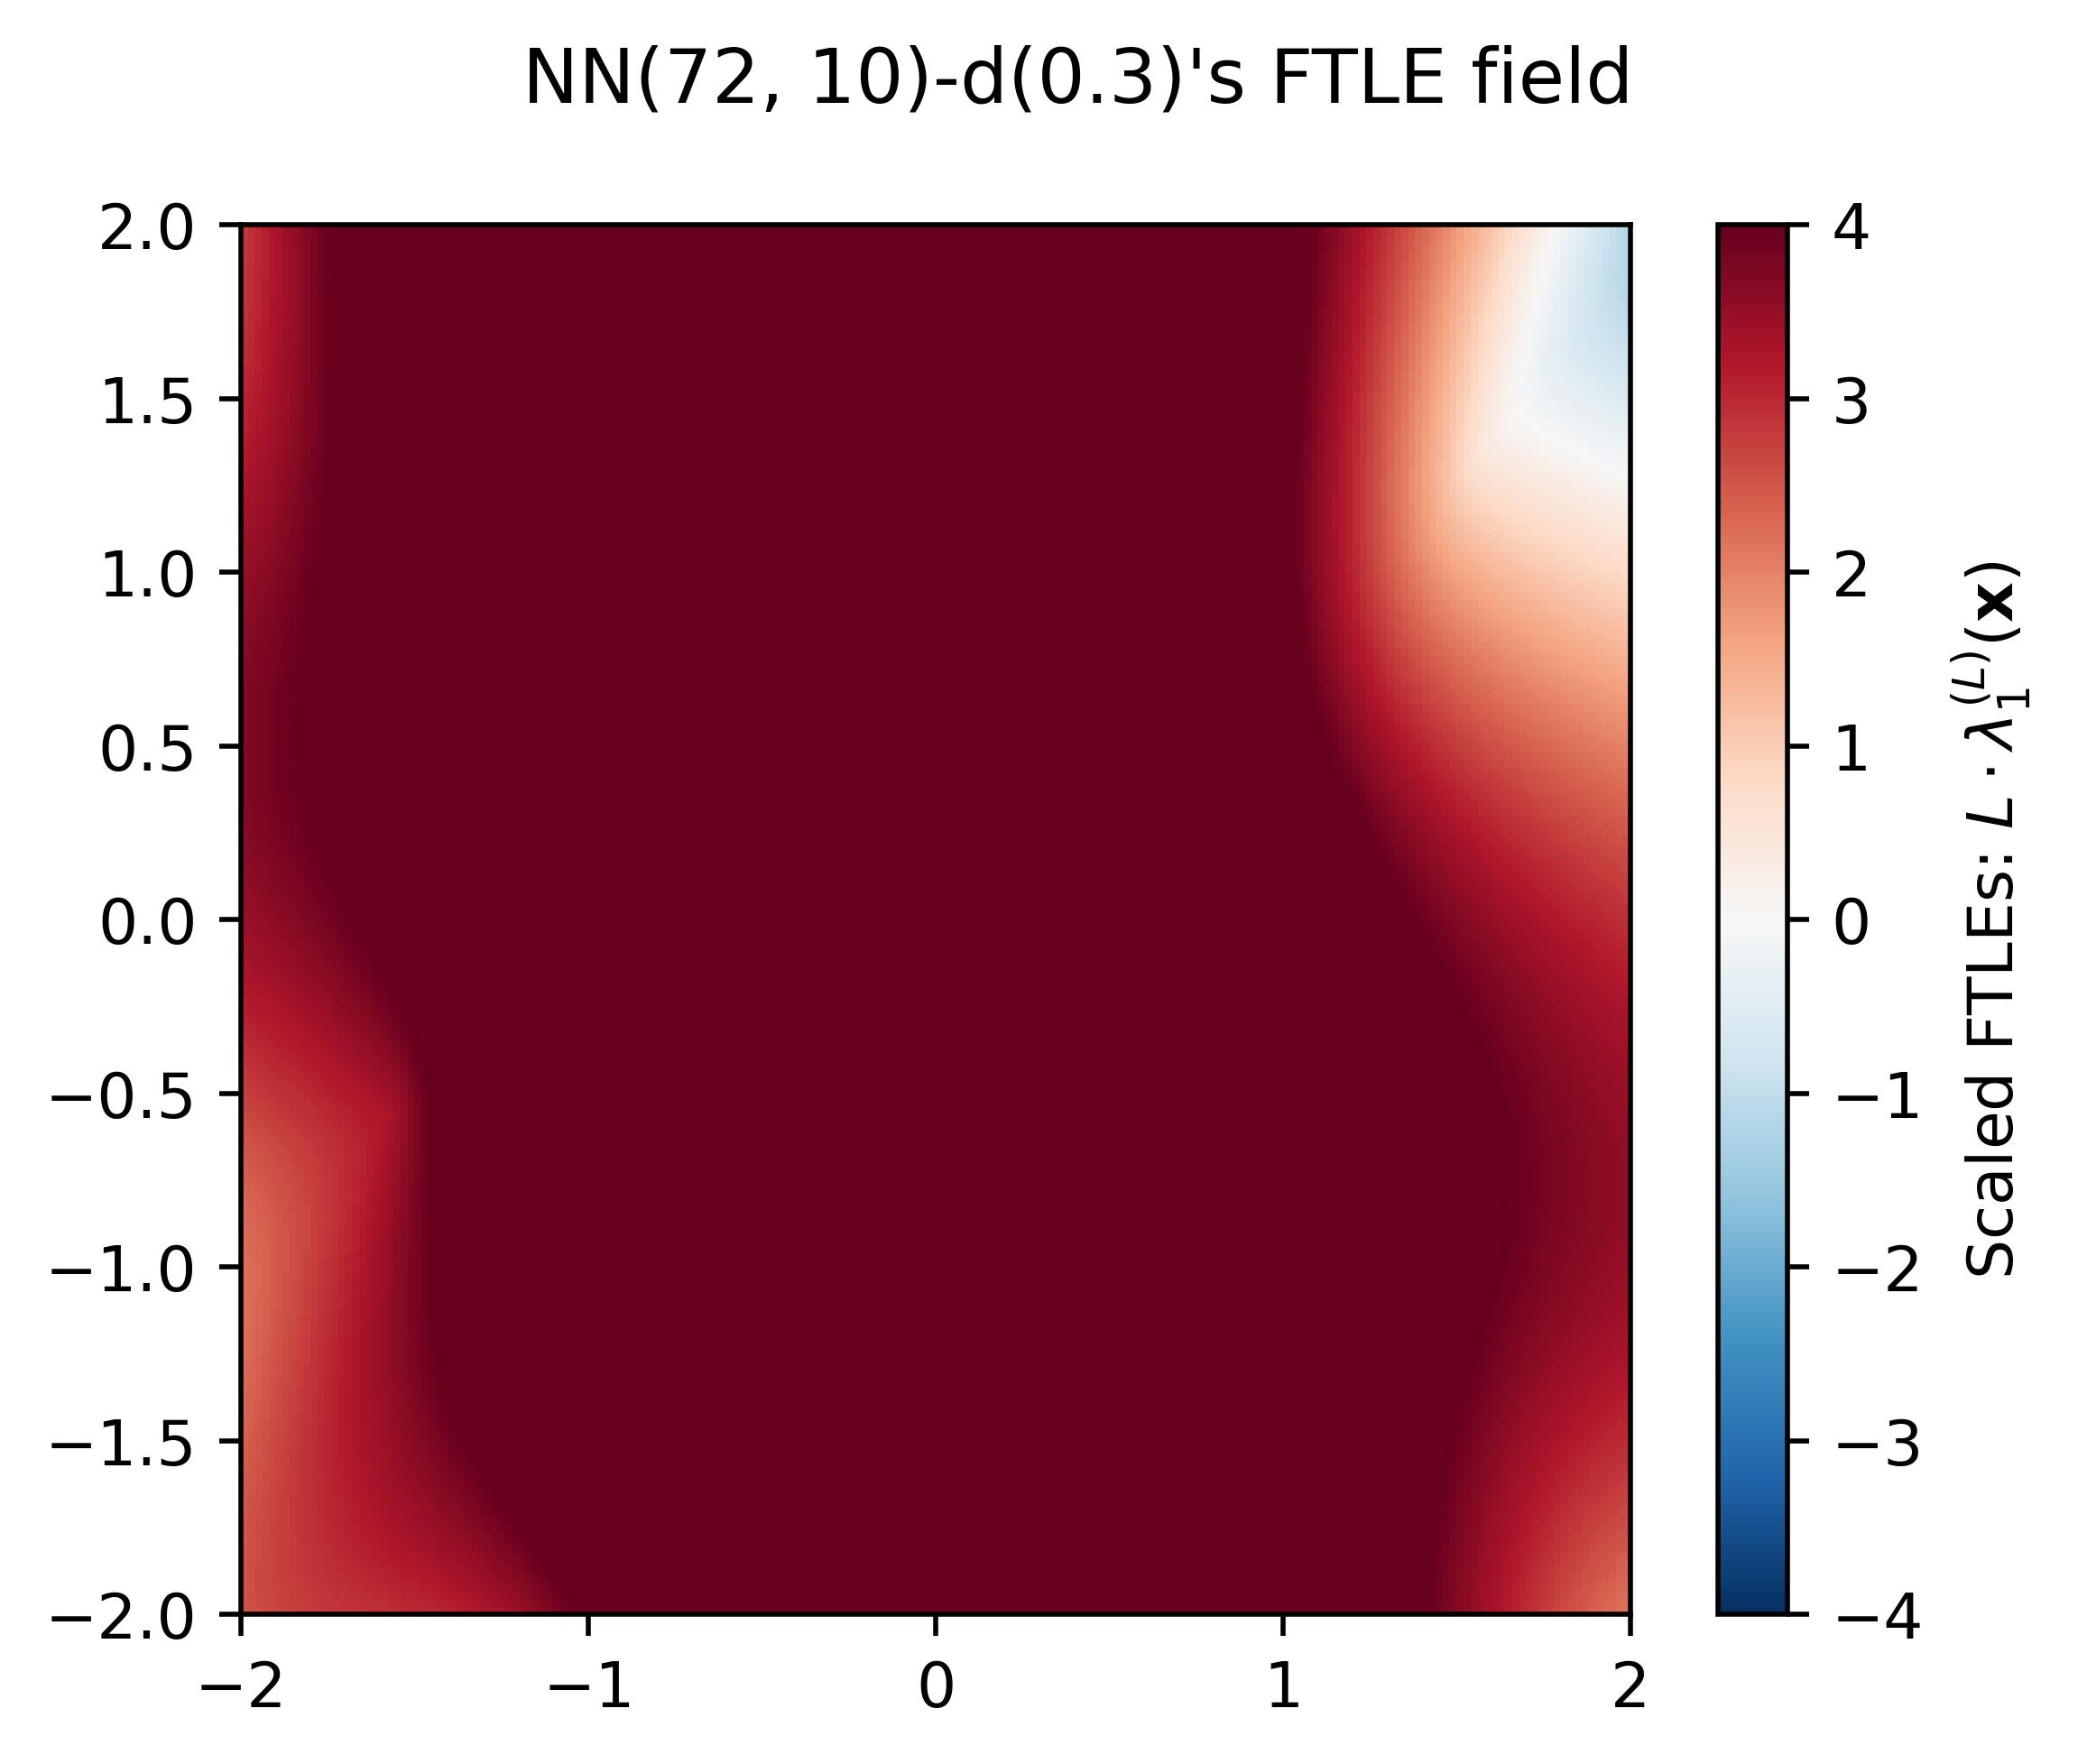

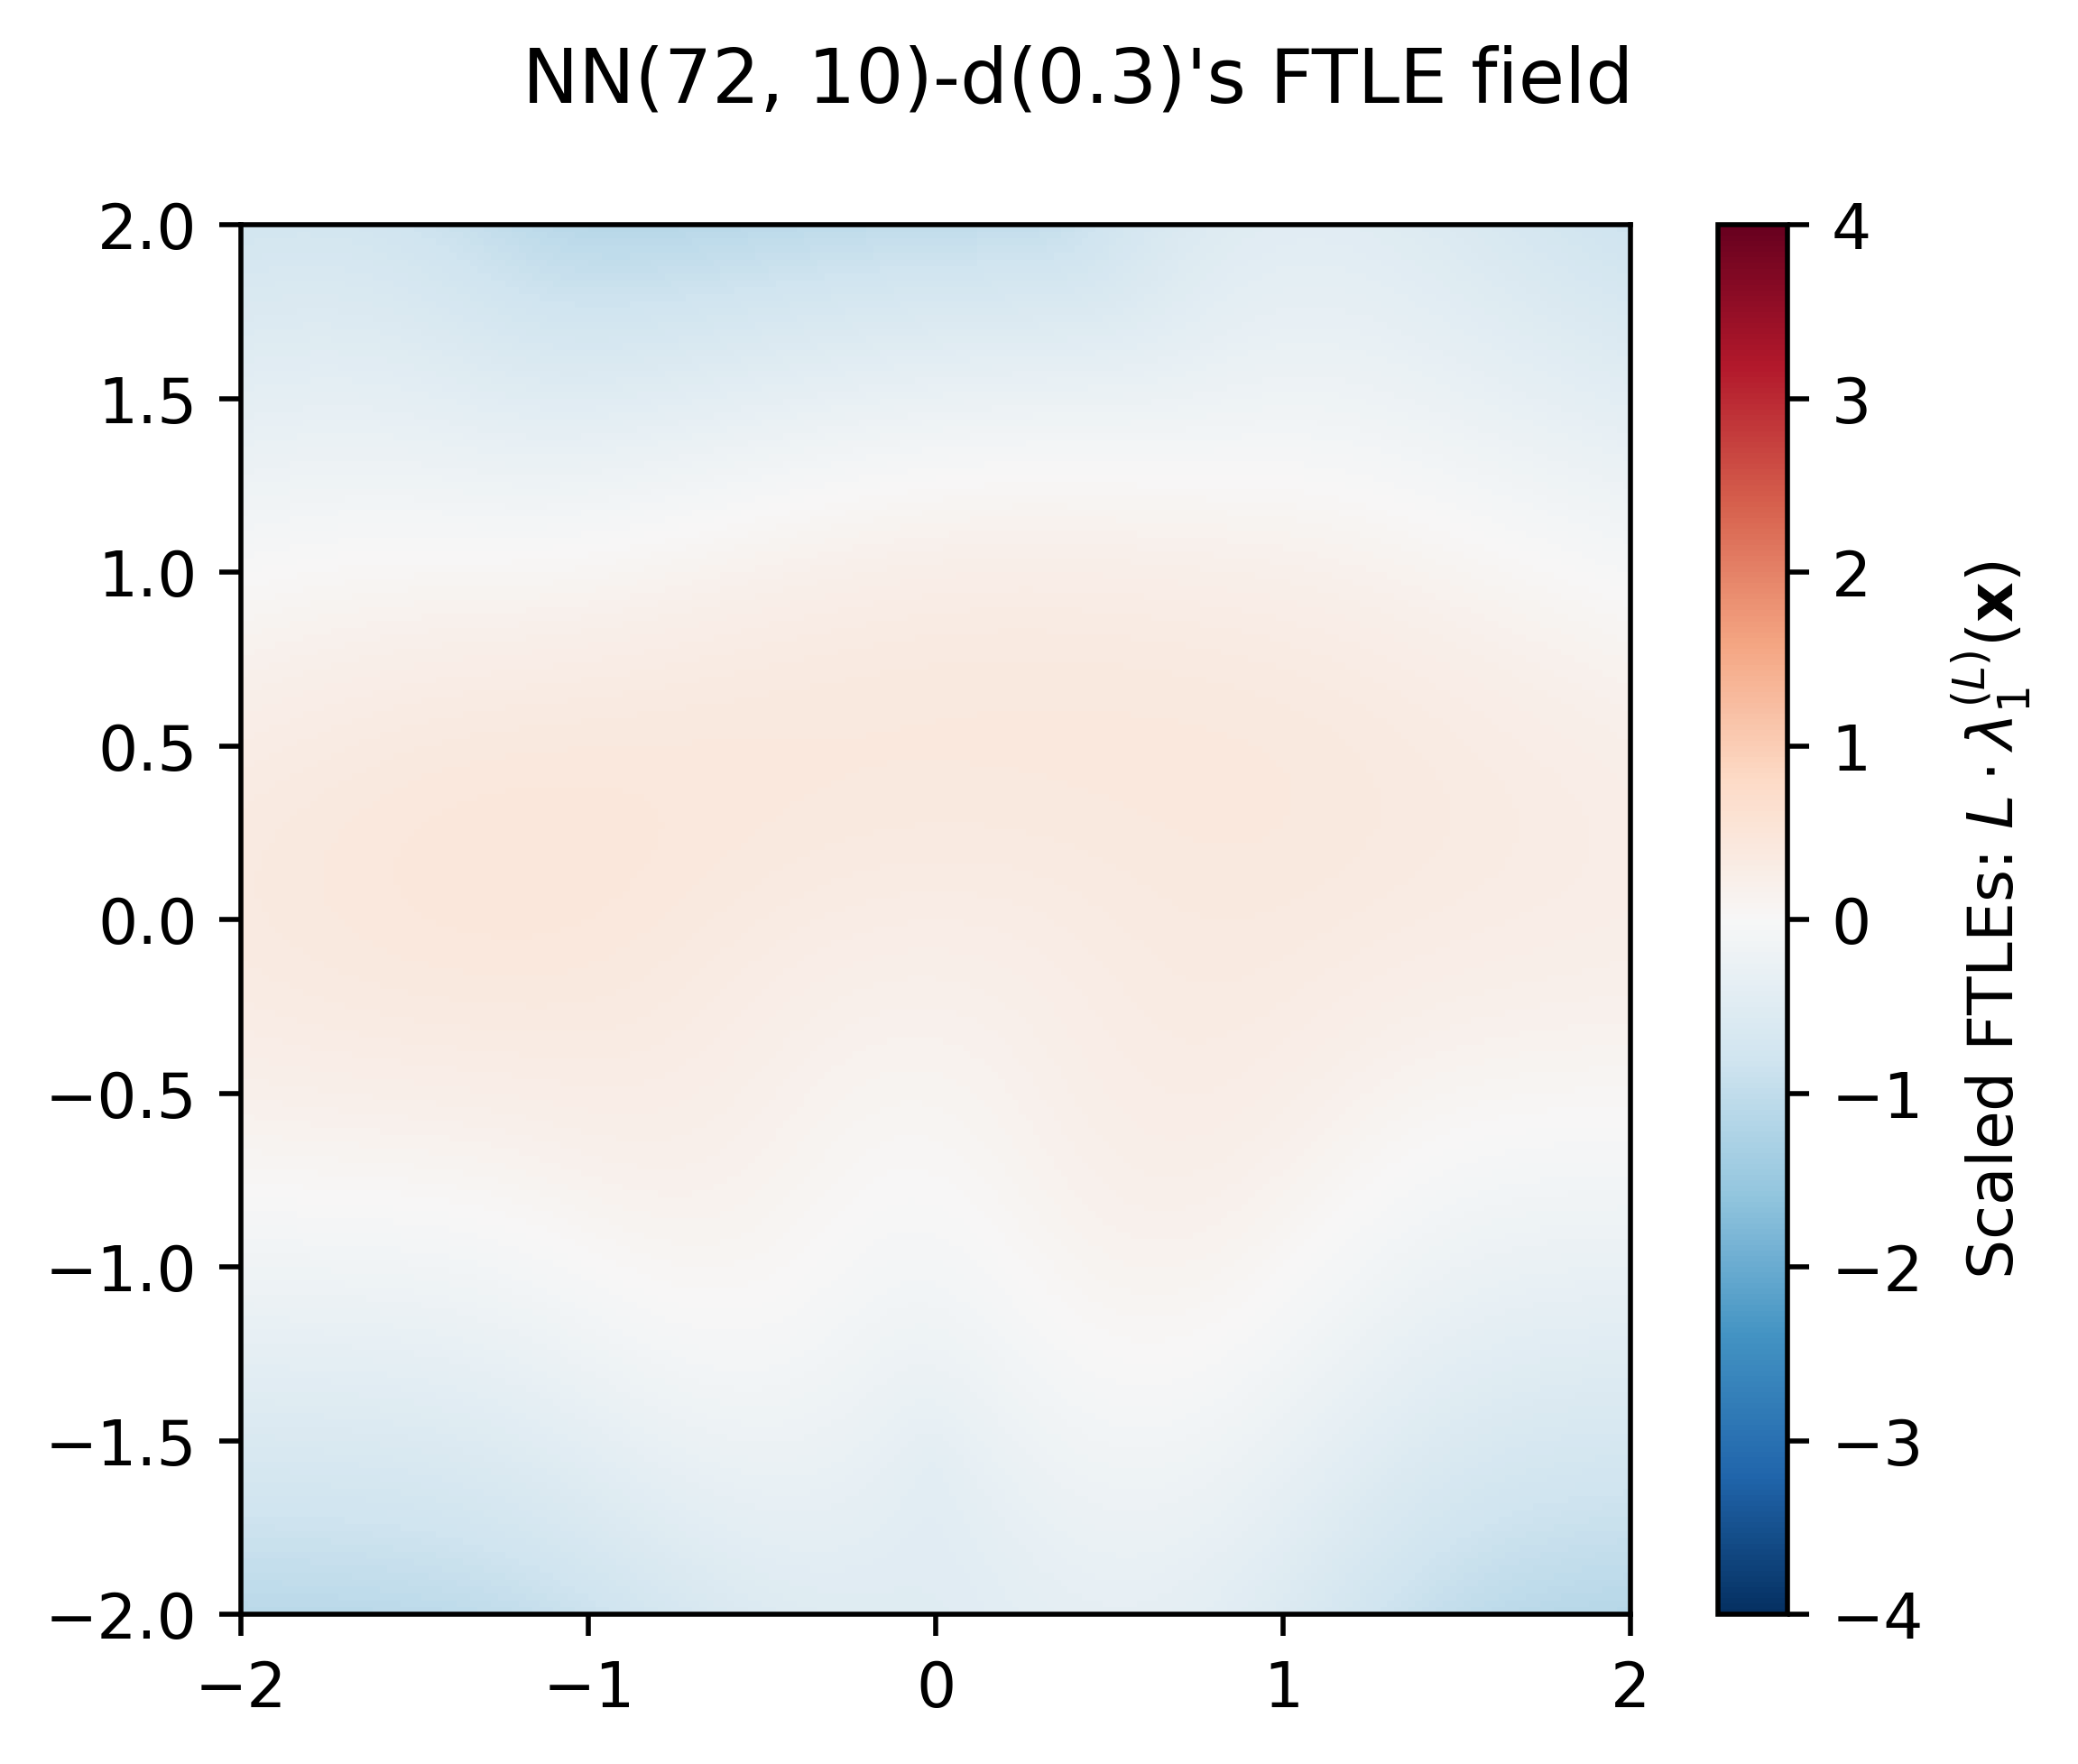

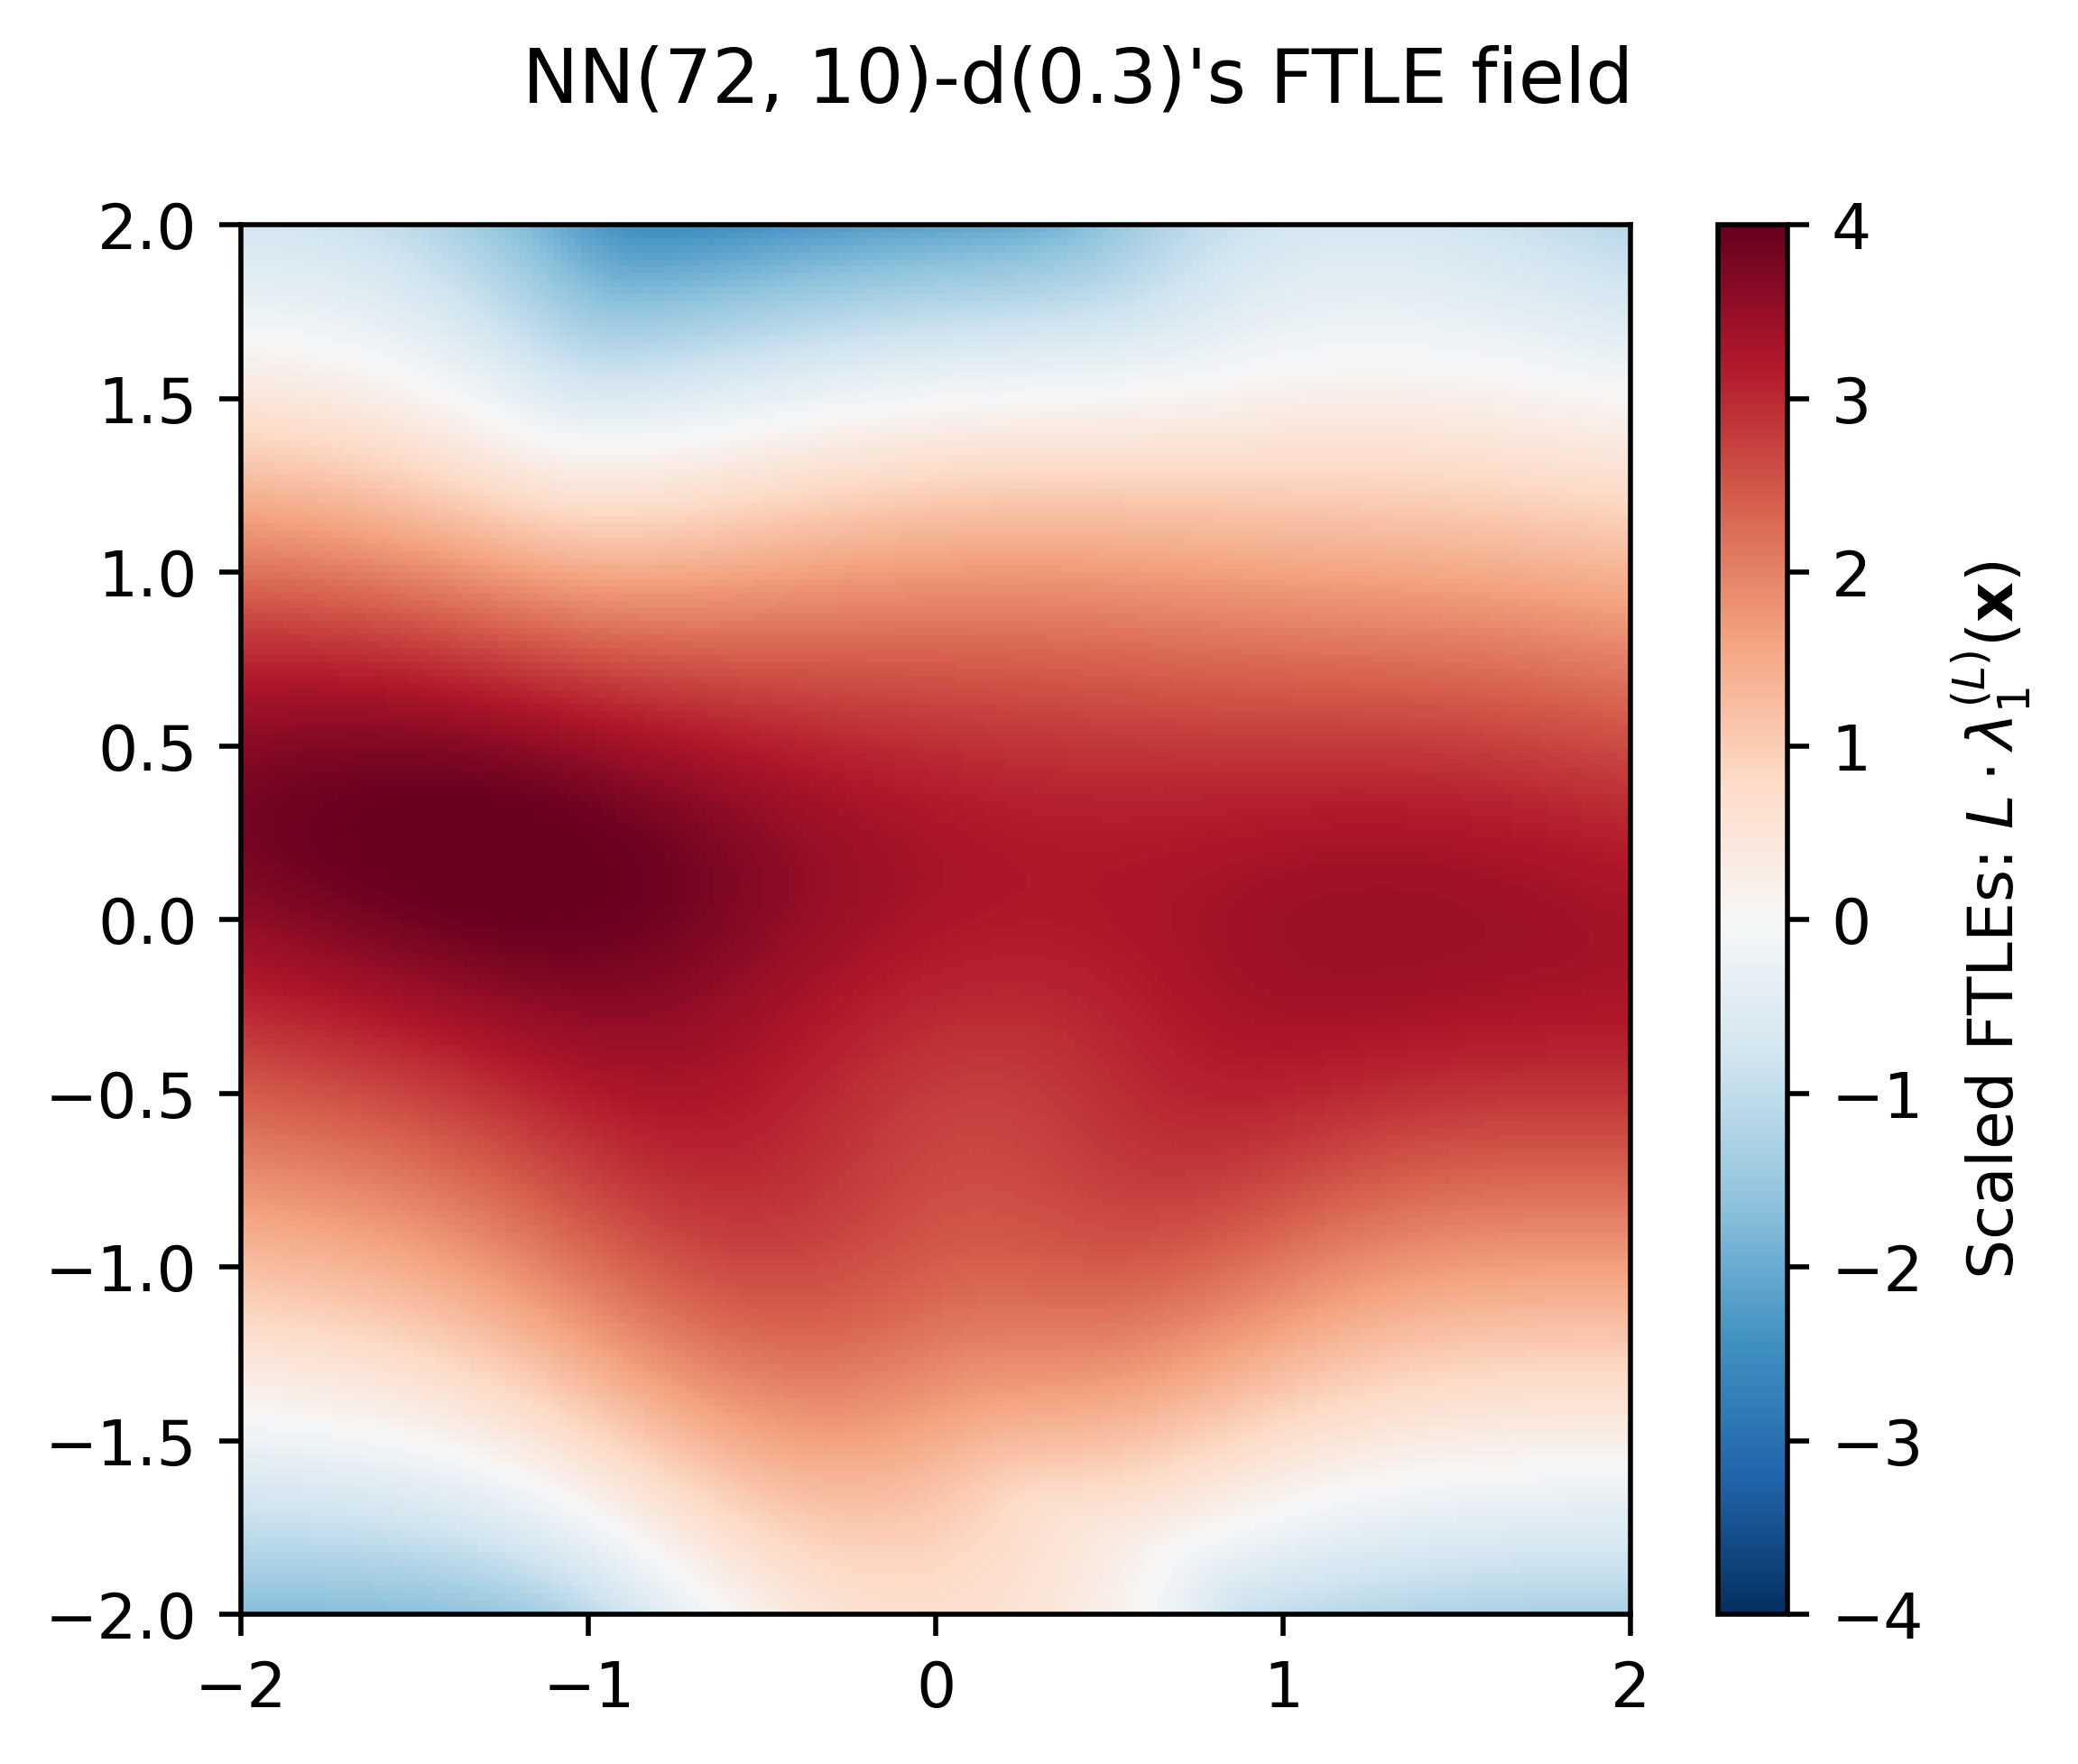

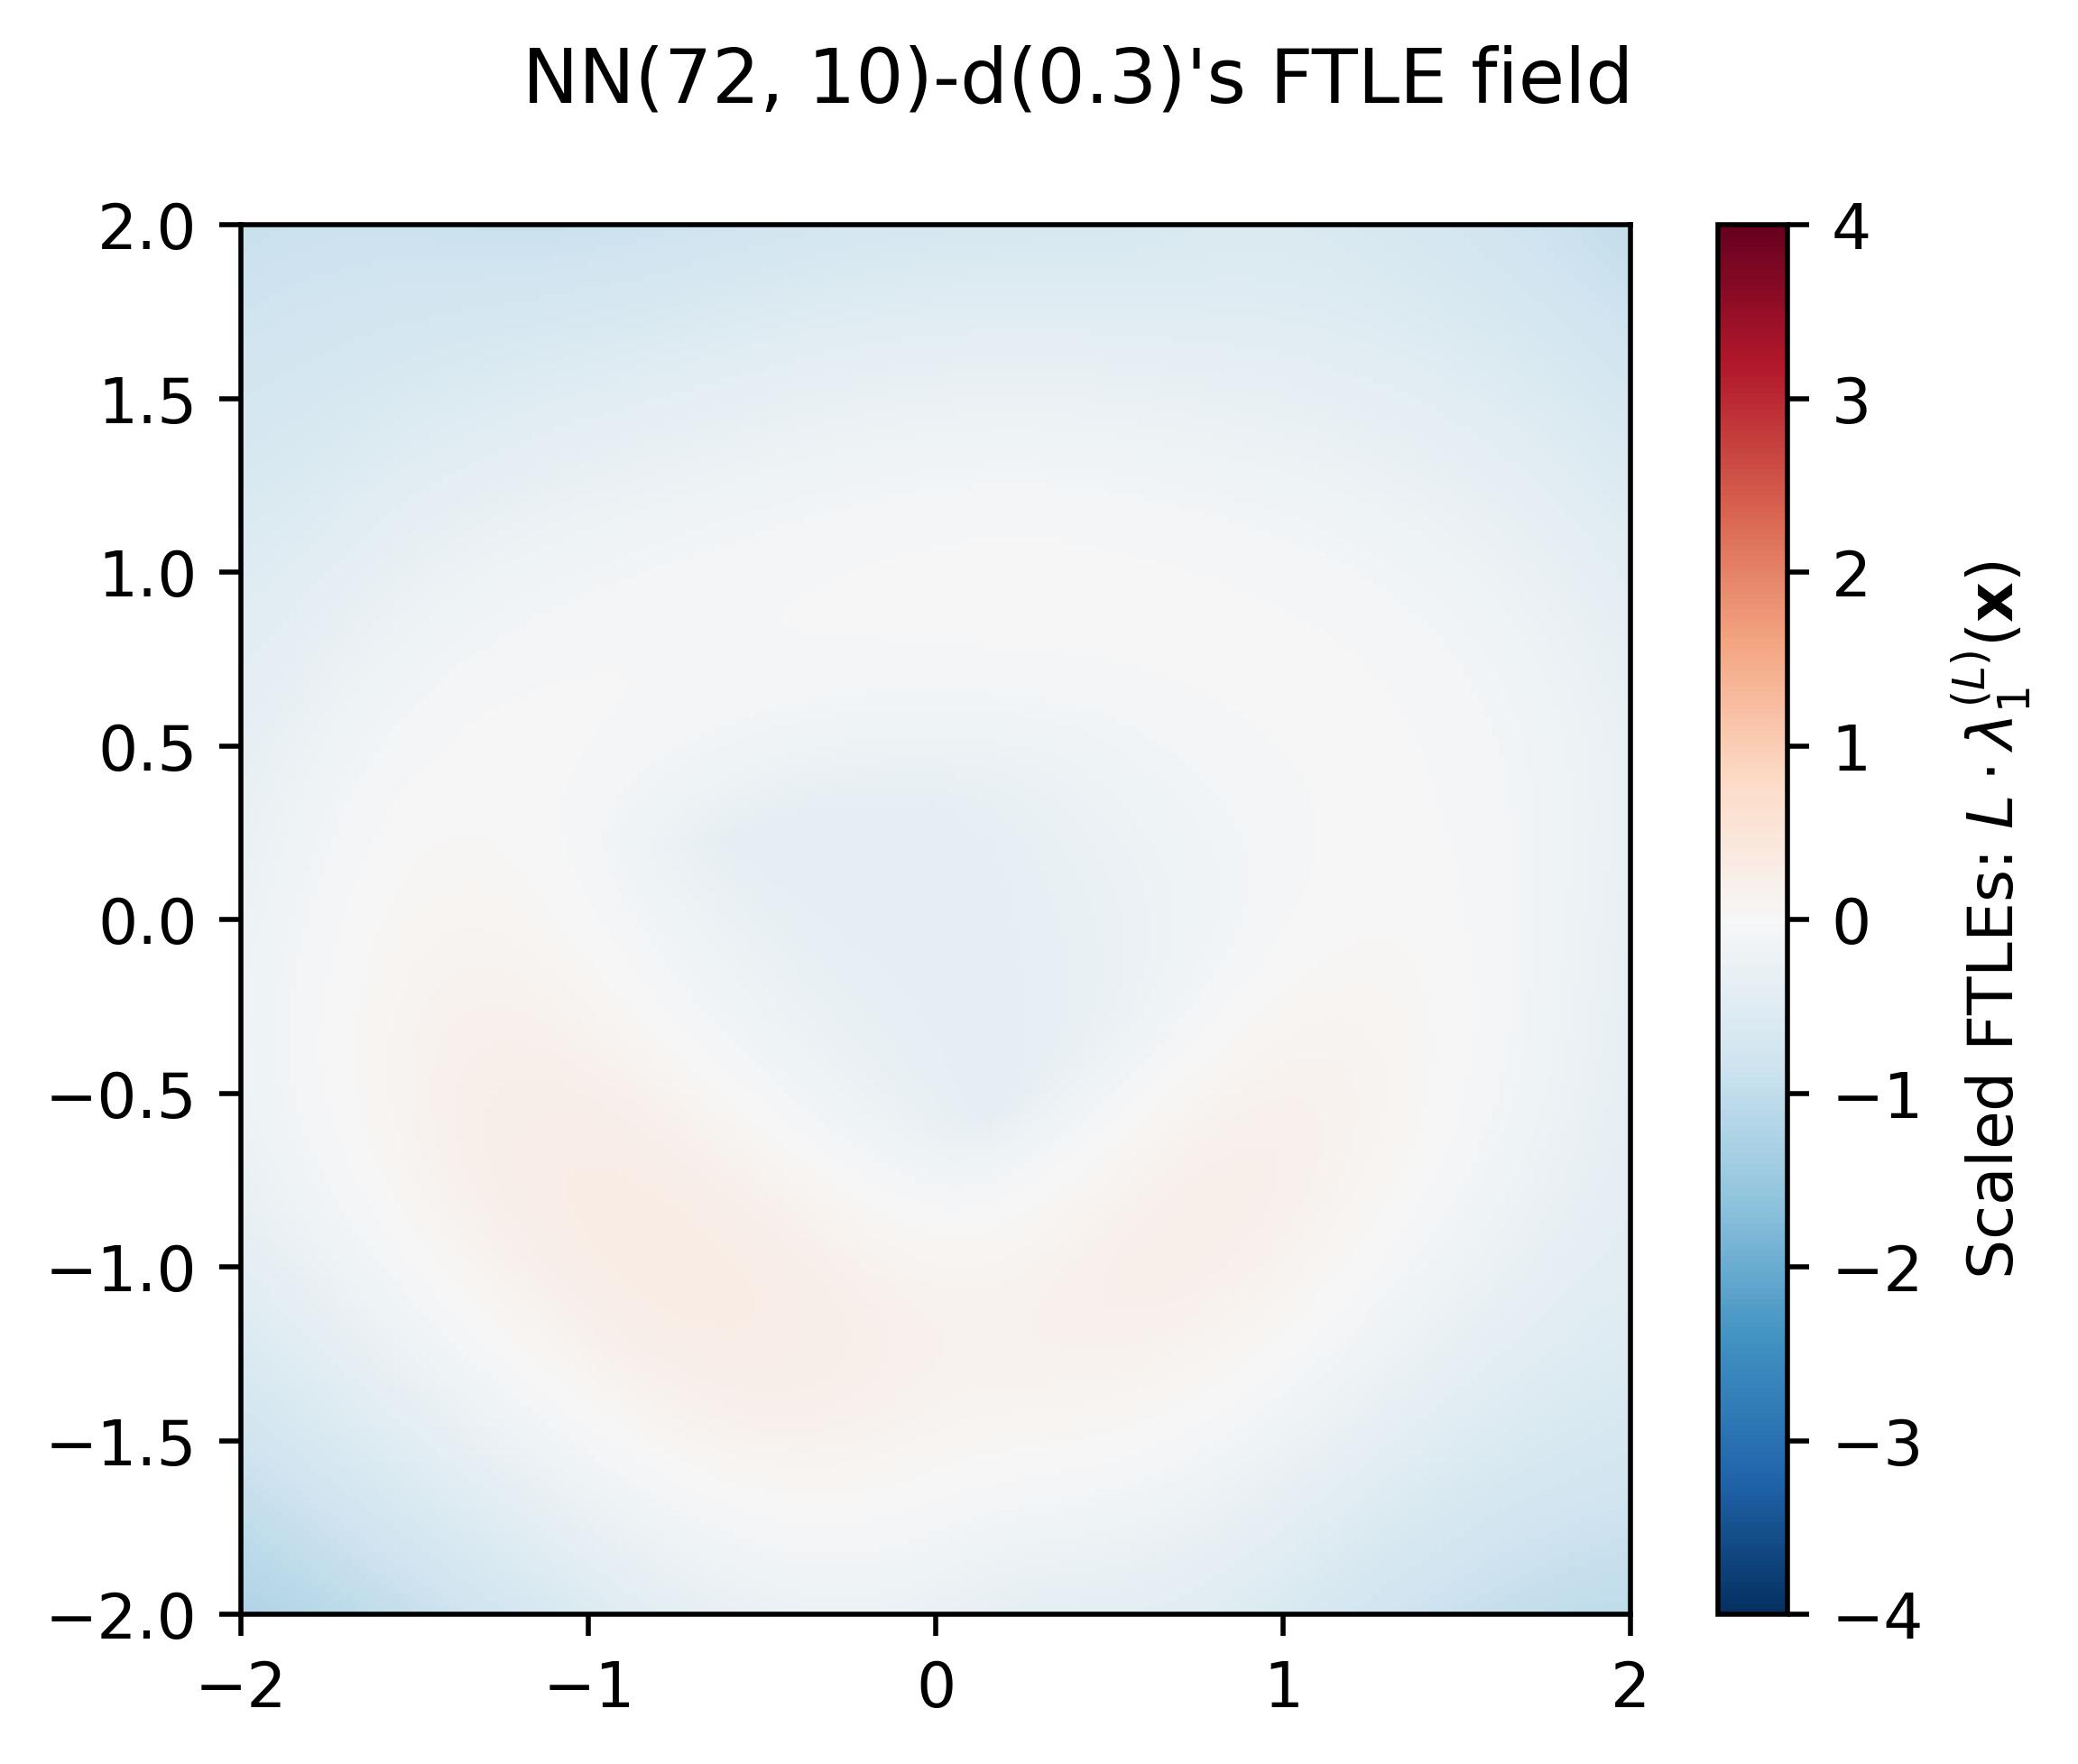

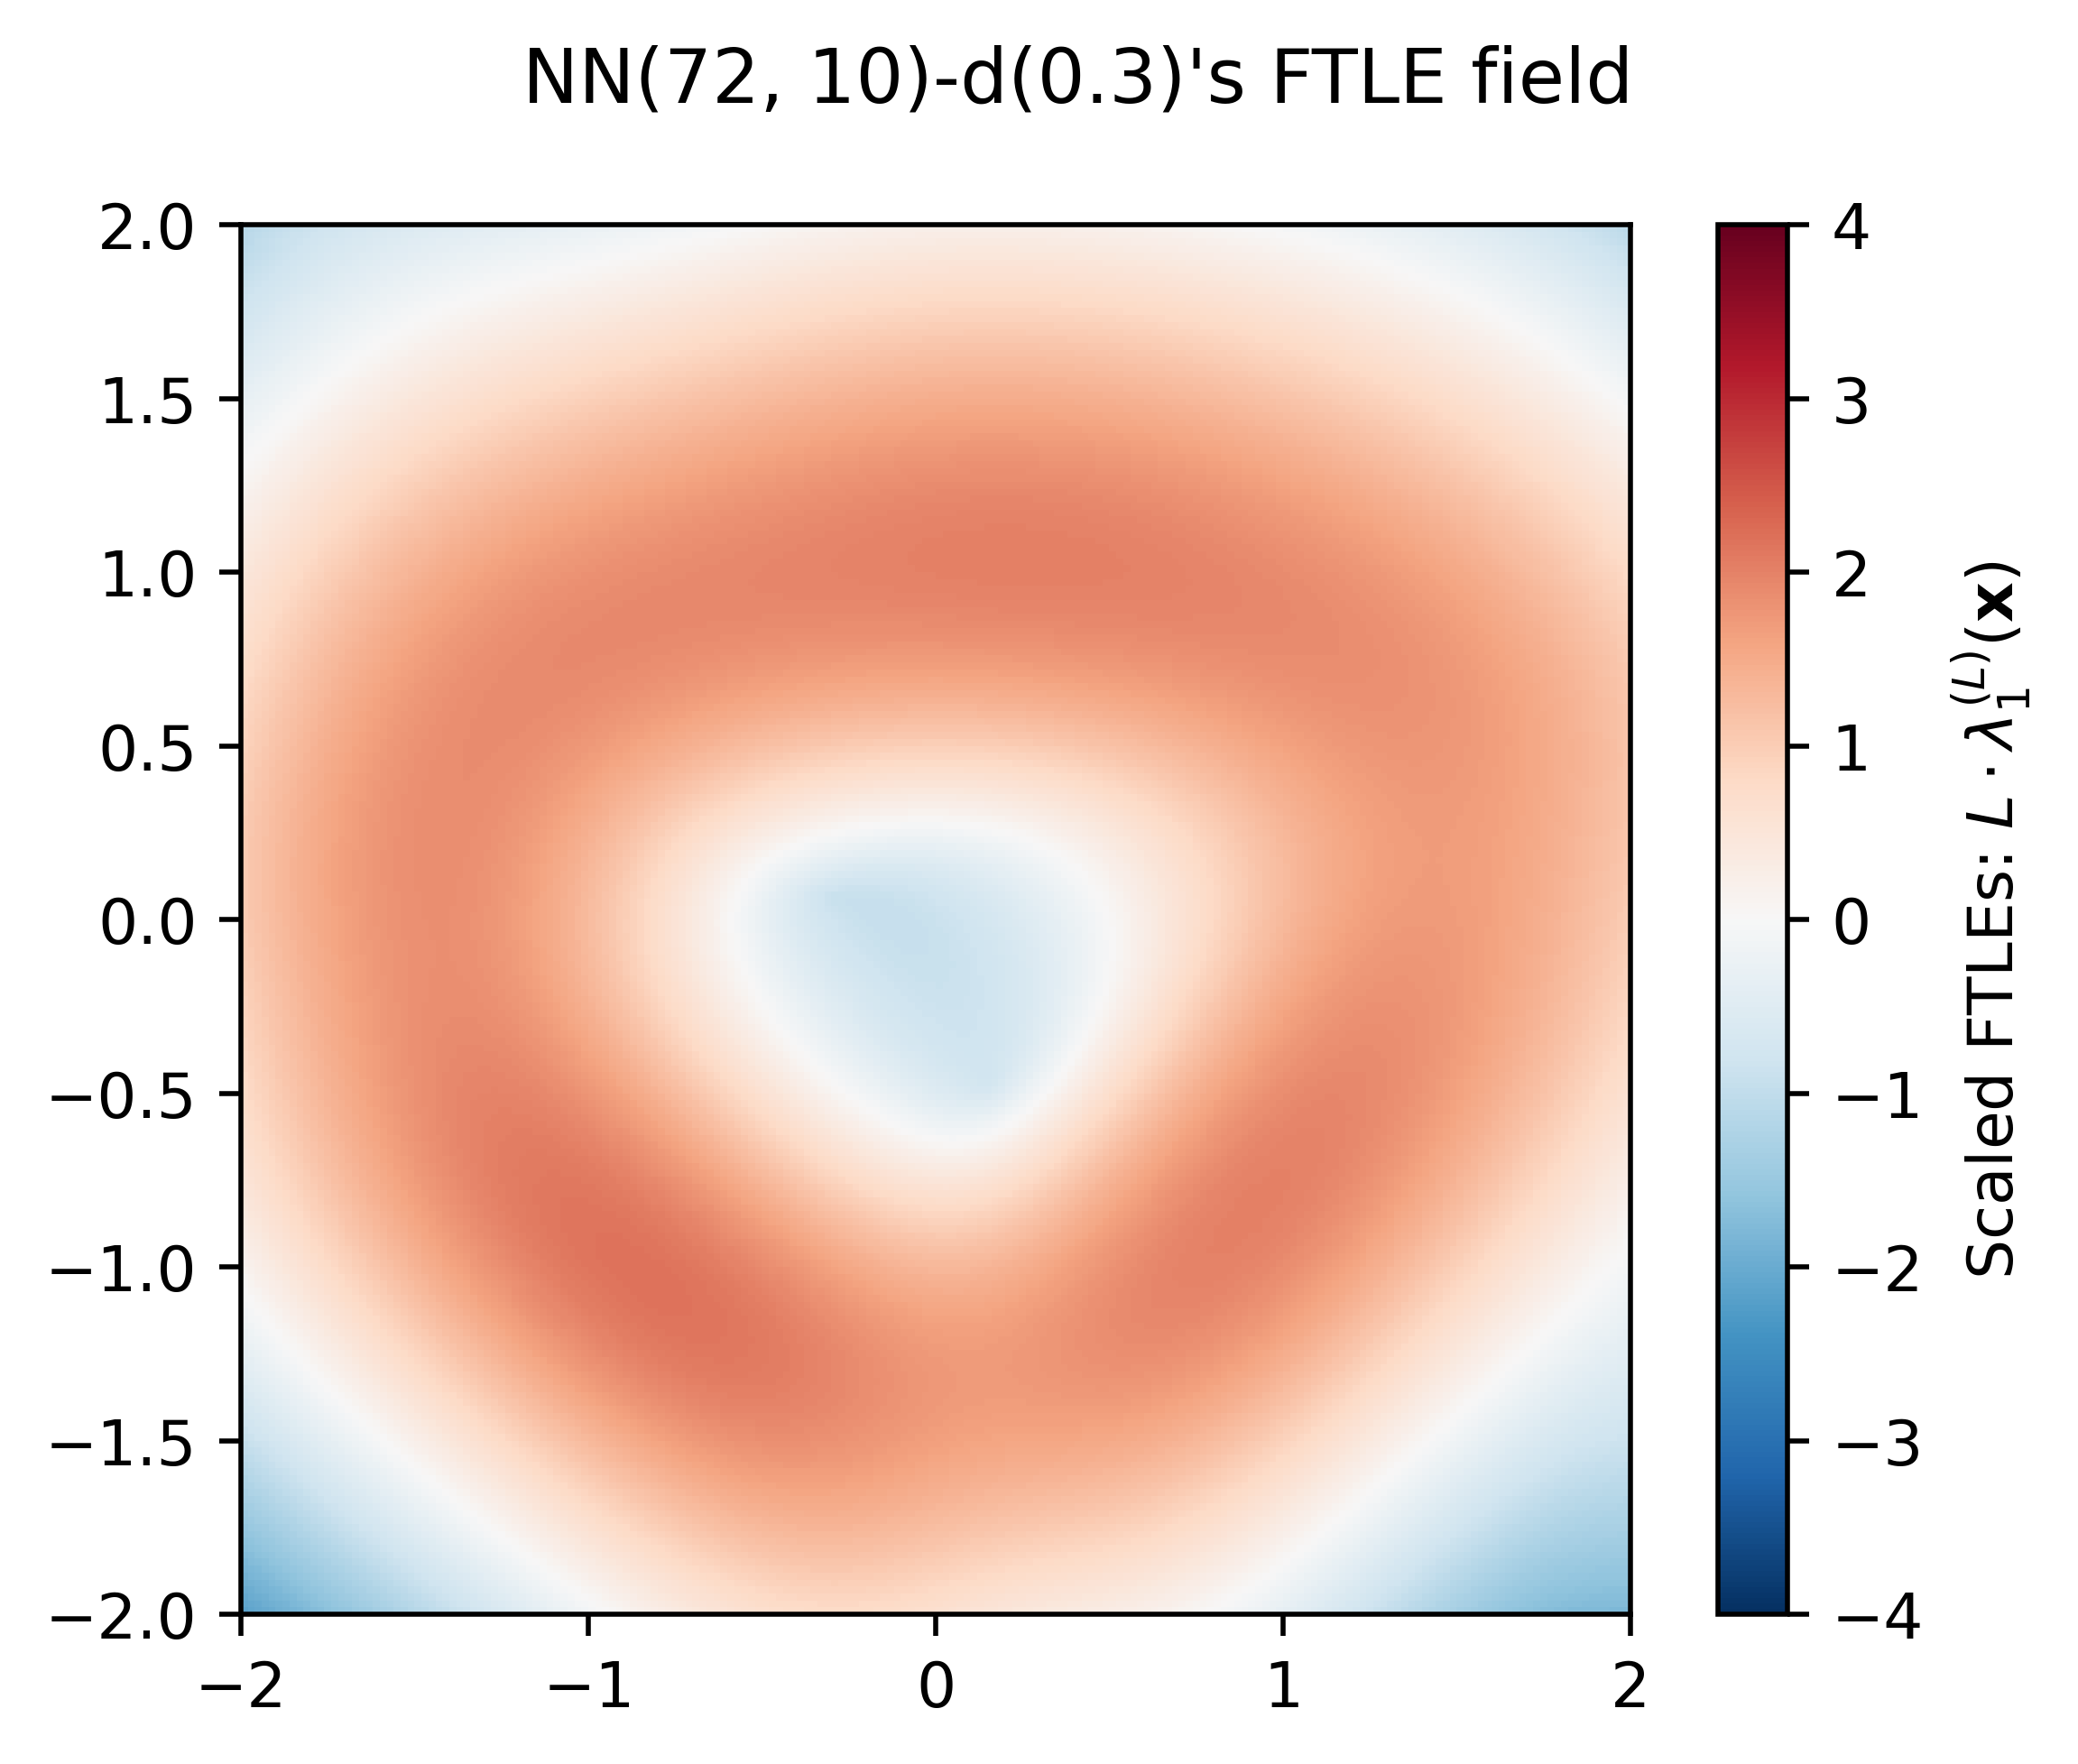

In [23]:
# 5) Plot (matplotlib)
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

for i in range(5):
    fig = plt.figure(figsize=(5,4), dpi=500)
    plt.imshow(l_list[i] * grids_jax[i].reshape(200, 200),
            extent=(-2,2,-2,2), 
            origin="lower", 
            aspect="equal",
            cmap="RdBu_r",
            norm=TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4))
    plt.colorbar(label=r"Scaled FTLEs: $L\cdot\lambda_1^{(L)}(\mathbf{x})$", norm='log')
    fig.suptitle(r"NN(72, 10)-d(0.3)'s FTLE field")
    plt.show()

In [31]:
grids_jax[0].reshape(200, 200)

array([[ 0.25571367,  0.25894892,  0.26177534, ...,  0.22545402,
         0.22112842,  0.21668054],
       [ 0.25569484,  0.25908887,  0.26206443, ...,  0.22864938,
         0.224456  ,  0.22014825],
       [ 0.25560677,  0.25914627,  0.26225704, ...,  0.2316327 ,
         0.22755818,  0.22337593],
       ...,
       [ 0.28364035,  0.29357815,  0.30280975, ..., -0.09616561,
        -0.10492579, -0.11396156],
       [ 0.28350505,  0.2935452 ,  0.30286258, ..., -0.09451883,
        -0.10358464, -0.11297094],
       [ 0.28342757,  0.29357585,  0.30298084, ..., -0.09246618,
        -0.10183908, -0.11158232]], shape=(200, 200), dtype=float32)

## Grid Experimenting + Variations

### Datasets

In [3]:
total_size = 15000
train_size = int(0.8 * total_size)

In [4]:
### Circles
X_circ, y_circ = datasets.make_circle_dataset(num_samples=total_size,
                                              noise_std=0.0,
                                              seed=42)

data_circ = datasets.make_dataloaders(datasets.split_dataset(X_circ, y_circ, seed=42), batch_size=train_size)

### Moons
X_moons, y_moons = datasets.make_moons_dataset(num_samples=total_size,
                                               noise_std=0.0,
                                               seed=42)
data_moons = datasets.make_dataloaders(datasets.split_dataset(X_moons, y_moons, seed=42), batch_size=train_size)

### Spirals
X_spiral, y_spiral = datasets.make_spiral_dataset(num_samples=total_size,
                                                  noise_std=0.0,
                                                  seed=42)
data_spiral = datasets.make_dataloaders(datasets.split_dataset(X_spiral, y_spiral, seed=42), batch_size=train_size)

### Xor
X_xor, y_xor = datasets.make_xor_dataset(num_samples=total_size,
                                         noise_std=0.0,
                                         seed=42)
data_xor = datasets.make_dataloaders(datasets.split_dataset(X_xor, y_xor, seed=42), batch_size=train_size)

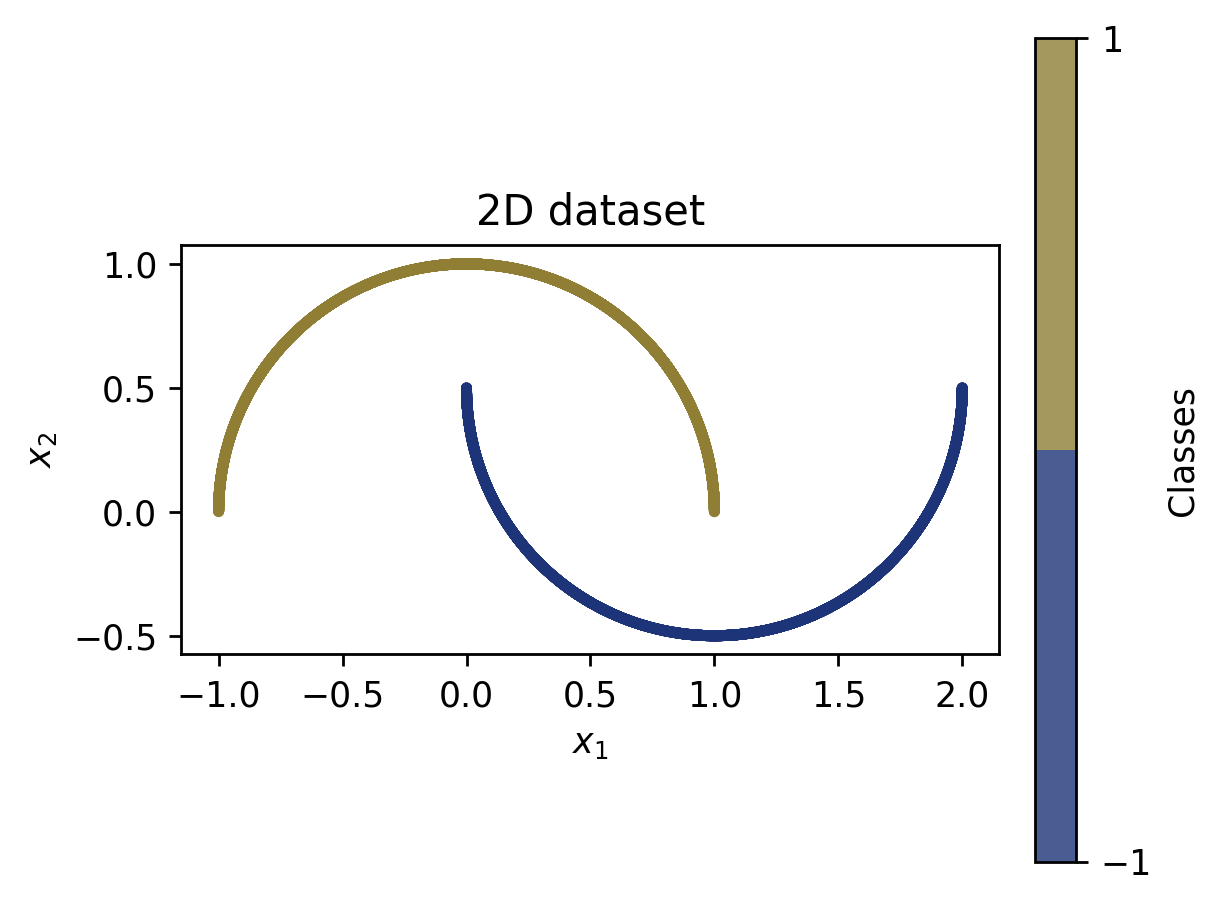

In [17]:
fl.data.plot_2d_dataset(X_moons, y_moons)

In [5]:
dataset_names = ["circle", "moons", "spiral", "xor"]
datasets_dict = {
    "circle": data_circ,
    "moons": data_moons,
    "spiral": data_spiral,
    "xor": data_xor,
}

| Variation | Weak | Medium | Strong |
| ---- | ---- | ---- | ---- |
| Constant | `[30, 30, 30, 30, 30]` | - | - | 
| Expansion | `[20, 25, 30, 35, 40]` | `[10, 20, 30, 40, 50]` | `[5, 10, 20, 40, 80]` |
| Contraction | `[40, 35, 30, 25, 20]` | `[50, 40, 30, 20, 10]` | `[80, 40, 20, 10, 5]` |
| Symmetric | `[30, 20, 15, 20, 30]` | `[40, 20, 10, 20, 40]` | `[50, 25, 5, 25, 50]` |
| Alternating | `[30, 20, 30, 20, 30]` | `[30, 10, 30, 10, 30]` | `[40, 5, 40, 5, 40]` |

In [12]:
experiment_name = "4-variations"

In [13]:
baseline_dense_config = {
    "net_params": {
        "layer_sizes": [2, 30, 30, 30, 30, 30, 1],
        "init_method": "paper",
        "output_activation": "tanh",
    },
    "train_config":
    training.TrainConfig(
        lr=1e-2, 
        epochs=2000, # 2500,
        batch_size=train_size, # 256,
        loss='mse',
        optimizer='sgd',
        weight_decay=0.0,
        save_dir=f'experiment_{experiment_name}',
        model_name='baseline_dense',
        momentum=0.0,
        print_every=400, #200
    )
}

In [14]:
networks_grid_variations = {
    "expansion": {
        "weak": [20, 25, 30, 35, 40],
        "medium": [10, 20, 30, 40, 50],
        "strong": [5, 10, 20, 40, 80],
    },
    "contraction": {
        "weak": [40, 35, 30, 25, 20],
        "medium": [50, 40, 30, 20, 10],
        "strong": [80, 40, 20, 10, 5],
    },
    "symmetric": {
        "weak": [30, 20, 15, 20, 30],
        "medium": [40, 20, 10, 20, 40],
        "strong": [50, 25, 5, 25, 50],
    },
    "alternating": {
        "weak": [30, 20, 30, 20, 30],
        "medium": [30, 10, 30, 10, 30],
        "strong": [40, 5, 40, 5, 40],
    }
}

In [15]:
networks_grid_variations_configs = {}

for dataset_name in dataset_names:
    networks_grid_variations_configs[dataset_name] = {}
    for key in networks_grid_variations.keys():
        for strength in networks_grid_variations[key].keys():
            config_key = f"{key}_{strength}-{dataset_name}"
            layer_sizes = [2] + networks_grid_variations[key][strength] + [1]
            networks_grid_variations_configs[dataset_name][config_key] = {
                "net_params": {
                    "layer_dims": layer_sizes,
                    "init_method": "paper",
                    "output_activation": "tanh",
                },
                "train_config":
                training.TrainConfig(
                    lr=1e-2, 
                    epochs=2000, # 2500,
                    batch_size=train_size, # 256,
                    loss='mse',
                    optimizer='sgd',
                    weight_decay=0.0,
                    save_dir=f'experiment_{experiment_name}/{dataset_name}',
                    model_name=f"__{config_key}",
                    momentum=0.0,
                    print_every=1000, #200
                )
            }

### Circles

In [25]:
for dataset_name in dataset_names:
    for network in tqdm(networks_grid_variations_configs[dataset_name].keys()):
        net = fmods.DenseNet(**networks_grid_variations_configs[dataset_name][network]["net_params"])

        trainer = training.Trainer(net, networks_grid_variations_configs[dataset_name][network]["train_config"])
        trainer.train(datasets_dict[dataset_name]['train'], datasets_dict[dataset_name]['val'])

  0%|          | 0/12 [00:00<?, ?it/s]

Trainer for MODEL___expansion_weak-spiral initialized on device: cuda
Trainable parameters: 3,931 / 3,931
Training started...


Epoch 1000/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 89.06it/s]


Epoch 1000/2000 | Train Loss: 0.8458 | Val Loss: 0.8465 | Val accuracy: 0.6406
Validation loss improved from 0.8466 to 0.8465. Saving best model.


  8%|▊         | 1/12 [03:30<38:40, 210.91s/it]

...

Epoch 2000/2000 | Train Loss: 0.0388 | Val Loss: 0.0445 | Val accuracy: 0.9956
Validation loss improved from 0.0445 to 0.0445. Saving best model.
Training finished.
Trainer for MODEL___alternating_strong-xor initialized on device: cuda
Trainable parameters: 1,051 / 1,051
Training started...


Epoch 1000/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 105.62it/s]


Epoch 1000/2000 | Train Loss: 0.0481 | Val Loss: 0.0539 | Val accuracy: 0.9922
Validation loss improved from 0.0539 to 0.0539. Saving best model.


100%|██████████| 12/12 [39:56<00:00, 199.71s/it]

Epoch 2000/2000 | Train Loss: 0.0294 | Val Loss: 0.0337 | Val accuracy: 0.9961
Validation loss improved from 0.0337 to 0.0337. Saving best model.
Training finished.


### Grid Experimenting + Different Datasets and Activations

In [16]:
networks_grid_tanh = {}
for dataset_name in dataset_names:
    networks_grid_tanh[dataset_name] = {}
    for network in networks_grid_variations_configs[dataset_name].keys():
        config = networks_grid_variations_configs[dataset_name][network]
        net = fmods.DenseNet(**config["net_params"])
        loaded_net = torch.load(f'experiment_{experiment_name}/{dataset_name}/LAST_CHECKPOINT__{network}.pt')
        net.load_state_dict(loaded_net['model_state_dict'])
        net.eval()
        networks_grid_tanh[dataset_name][network] = net

In [22]:
nx, ny = 200, 200

# circ
grid_circ, (XX, YY) = ftle.make_grid2d(-1.01, 1.01, -1.01, 1.01, nx=nx, ny=ny)
grid_circ_jax = jnp.asarray(grid_circ.numpy())

# moons
grid_moons, (XX_m, YY_m) = ftle.make_grid2d(-2, 2, -1.75, 2.25, nx=nx, ny=ny)
grid_moons_jax = jnp.asarray(grid_moons.numpy())

# spiral 
grid_spiral, (XX_s, YY_s) = ftle.make_grid2d(-2.2, 2.2, -2.2, 2.2, nx=nx, ny=ny)
grid_spiral_jax = jnp.asarray(grid_spiral.numpy())


# xor
grid_xor_jax = grid_circ_jax

In [25]:
grids_jax = {
    "circle": grid_circ_jax,
    "moons": grid_moons_jax,
    "spiral": grid_spiral_jax,
    "xor": grid_xor_jax
}

In [27]:
networks_grid_tanh_ftle = {}
for dataset_name in ["circle"]:
    networks_grid_tanh_ftle[dataset_name] = {}
    for network in networks_grid_tanh[dataset_name].keys():
        net = networks_grid_tanh[dataset_name][network]
    
        params_jax = pytorch_dense_to_jax_params(net)      
        networks_grid_tanh_ftle[dataset_name][f"{network}-ftle_fields"] = {}
        for depth in range(1, 6):
            lam_np = ftle_field_batched(
                model_type="dense",
                params=params_jax,
                X_np=grids_jax[dataset_name],
                layer_spec=("hidden_k", depth),
                time_L=depth,
                batch_size=2048,
                activation="tanh",
                output_activation="tanh",
                dtype="float32",
                max_steps=30
            )
            lam_np.reshape(YY.shape)
            networks_grid_tanh_ftle[dataset_name][f"{network}-ftle_fields"][f"layer-{depth}"] = lam_np
             

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

...

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

In [28]:
networks_grid_tanh_ftle["circle"]

{'expansion_weak-circle-ftle_fields': {'layer-1': array([0.8079836 , 0.8075081 , 0.8070942 , ..., 0.650778  , 0.64329153,
         0.6361705 ], shape=(40000,), dtype=float32),
  'layer-2': array([0.3922066 , 0.39512694, 0.3982838 , ..., 0.34344038, 0.3375415 ,
         0.33194   ], shape=(40000,), dtype=float32),
  'layer-3': array([0.18089694, 0.18369906, 0.18670437, ..., 0.14496964, 0.141008  ,
         0.1373471 ], shape=(40000,), dtype=float32),
  'layer-4': array([0.17098694, 0.17386034, 0.17685486, ..., 0.12728162, 0.12381998,
         0.12065479], shape=(40000,), dtype=float32),
  'layer-5': array([0.12469592, 0.12755214, 0.13058649, ..., 0.09882694, 0.09560821,
         0.09261757], shape=(40000,), dtype=float32)},
 'expansion_medium-circle-ftle_fields': {'layer-1': array([0.62678856, 0.6293754 , 0.63203734, ..., 0.5426728 , 0.5457604 ,
         0.5486884 ], shape=(40000,), dtype=float32),
  'layer-2': array([0.49842277, 0.50108135, 0.503724  , ..., 0.45476162, 0.45573482,
    

In [ ]:



fig = plt.figure(constrained_layout=True, figsize=(18,18), dpi=100)
axes = fig.subplots(4, 3)

# Iterate over each grid
for i, result in enumerate(networks_grid_tanh_ftle['spiral'].values()):
    ax = axes[i%4, i//4]
    L = ell_list[i//4]
    lyapunov_exponents = L * result.reshape(nx, ny)
    
    # Plot the heatmap
    im = ax.imshow(lyapunov_exponents,
                   extent=[-1.5, 1.5, -1.5, 1.5],
                   origin='lower',
                   cmap='RdBu_r',
                   alpha=0.9,
                   norm=TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)) # vmin/vmax=-+4
    
    color_string = 'black' #'white' if (i%4 * 5 + i//4) + 1 in [2, 3, 4, 5, 10] else 'black'
    ax.text(-1.8, 1.5, f"[{(i%4 * 4 + i//4) + 1}]", color=color_string, fontsize=20)

    # Add vector field

    if not i % 4:
        ax.set_xlabel(f"L = {ell_list[i//4]}", fontsize=20)
        ax.xaxis.set_label_position('top') 
    if i in range(4):
        ax.set_ylabel(f"N = {n_list[i]}", fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])

# Add a colorbar to the right of the figure
# plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    orientation='horizontal',
                    location='bottom',
                    shrink=0.8)
                    # fraction=0.08, pad=0.05)
cbar.set_label(r"$L\lambda^{(L)}(\mathbf{x})$",fontsize=20)
cbar.ax.tick_params(labelsize=20)
# cbar.ax.xaxis.set_label_position('top')
# cbar.ax.xaxis.tick_top()
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_circle_ftle_grid(
    networks_grid_tanh_ftle,
    layer_key="layer-2",
    dataset_name="circle",
    nx=200,
    ny=200,
    extent=(-1.2, 1.2, -1.2, 1.2),
    cmap="RdBu_r",
    vmin=-3.0,
    vcenter=0.0,
    vmax=3.0,
    scale_by_L=False,
    L=None,
    figsize=(12, 14),
    dpi=120,
):
    """
    Plot FTLE fields for the circle dataset in a 4x3 grid:
      rows    = variation type
      columns = strength level

    Expected dict format:
    networks_grid_tanh_ftle[dataset_name][model_name][layer_key] -> flat FTLE array

    Example model name:
    'expansion_weak-circle-ftle_fields'
    """

    variation_order = ["expansion", "contraction", "symmetric", "alternating"]
    strength_order = ["weak", "medium", "strong"]

    fig, axes = plt.subplots(
        nrows=4,
        ncols=3,
        figsize=figsize,
        dpi=dpi,
        constrained_layout=True
    )

    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    dataset_dict = networks_grid_tanh_ftle[dataset_name]

    im = None

    for r, variation in enumerate(variation_order):
        for c, strength in enumerate(strength_order):
            ax = axes[r, c]

            model_name = f"{variation}_{strength}-{dataset_name}-ftle_fields"

            if model_name not in dataset_dict:
                ax.text(
                    0.5, 0.5,
                    f"Missing:\n{model_name}",
                    ha="center", va="center",
                    fontsize=11,
                    transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            model_result = dataset_dict[model_name]

            if layer_key not in model_result:
                ax.text(
                    0.5, 0.5,
                    f"Missing:\n{layer_key}",
                    ha="center", va="center",
                    fontsize=11,
                    transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            field = np.asarray(model_result[layer_key]).reshape(ny, nx)

            if scale_by_L:
                if L is None:
                    try:
                        L_eff = int(layer_key.split("-")[-1])
                    except Exception:
                        L_eff = 1
                else:
                    L_eff = L
                field = L_eff * field

            im = ax.imshow(
                field,
                extent=extent,
                origin="lower",
                cmap=cmap,
                norm=norm,
                alpha=0.95,
                aspect="auto",
            )

            ax.set_xticks([])
            ax.set_yticks([])

            if r == 0:
                ax.set_title(strength.capitalize(), fontsize=16, pad=12)

            if c == 0:
                ax.set_ylabel(variation.capitalize(), fontsize=16, rotation=90, labelpad=18)

    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        location="bottom",
        shrink=0.85,
        pad=0.04
    )

    if scale_by_L:
        cbar.set_label(r"$L\lambda^{(L)}(\mathbf{x})$", fontsize=16)
    else:
        cbar.set_label(r"$\lambda^{(L)}(\mathbf{x})$", fontsize=16)

    cbar.ax.tick_params(labelsize=12)

    fig.suptitle(f"FTLE fields for '{dataset_name}' at {layer_key}", fontsize=18, y=1.02)
    plt.show()

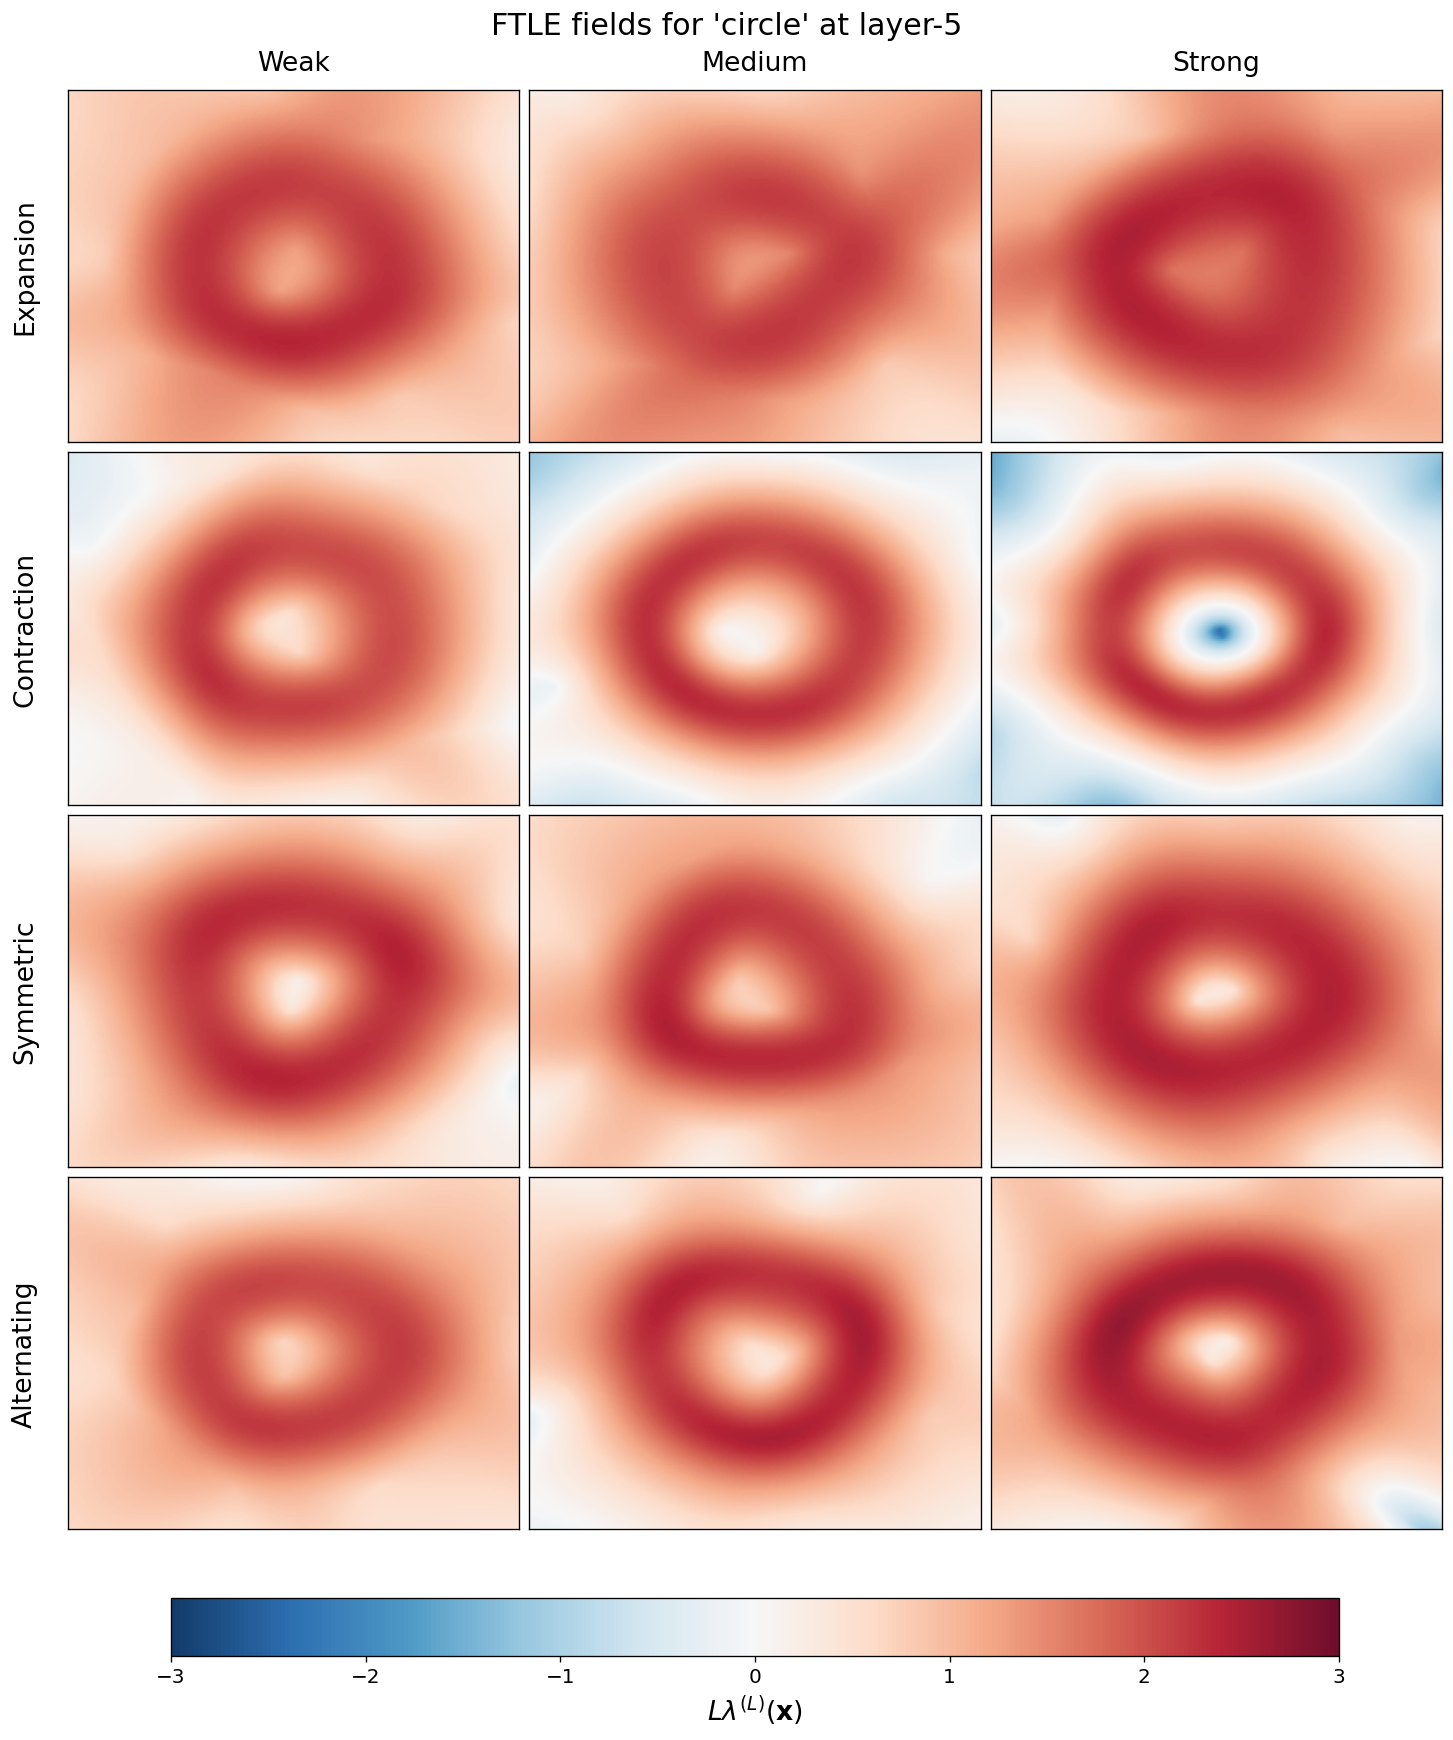

In [40]:
plot_circle_ftle_grid(
    networks_grid_tanh_ftle,
    layer_key="layer-5",
    dataset_name="circle",
    nx=200,
    ny=200,
    extent=(-1.2, 1.2, -1.2, 1.2),
    scale_by_L=True,
)